# Píldora 1 — Introducción a la Regresión Lineal
## ¿Cuánto debería ganar un profesional de datos?
### CLCD 121 · Ciencia de Datos · UGR

---

## El problema

Imaginá que estás en una entrevista de trabajo y te preguntan cuánto querés ganar.  
O que sos líder de un equipo y necesitás saber cuánto ofrecerle a un candidato.

**¿Existe alguna relación entre los años de experiencia y el salario en el sector de datos?**

En esta píldora vamos a construir un modelo matemático para responder esa pregunta.

In [ ]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
sns.set_style('whitegrid')
print('Librerías cargadas ✓')

Librerías cargadas ✓


In [ ]:
# ── Dataset: salarios en el sector de datos (Argentina, ficticio) ──
# Cada fila es un profesional encuestado.
# Experiencia: años trabajando en datos
# Salario: salario bruto mensual en miles de pesos

experiencia = np.array([0.5, 1, 1.5, 2, 2, 2.5, 3, 3, 3.5, 4,
                         4, 4.5, 5, 5, 5.5, 6, 6, 7, 7.5, 8,
                         8, 9, 9.5, 10, 10, 11, 12, 12, 13, 15])

# El salario crece con la experiencia, pero con algo de variabilidad natural
salario = 250 + 55 * experiencia + np.random.normal(0, 40, size=len(experiencia))
salario = np.round(salario, 1)

df = pd.DataFrame({'experiencia_anios': experiencia, 'salario_miles': salario})

print('Dataset de salarios en el sector de datos')
print(f'  Cantidad de profesionales encuestados: {len(df)}')
print(f'  Experiencia mínima: {df.experiencia_anios.min()} años')
print(f'  Experiencia máxima: {df.experiencia_anios.max()} años')
print(f'  Salario mínimo:  ${df.salario_miles.min():.1f}k')
print(f'  Salario máximo:  ${df.salario_miles.max():.1f}k')
print()
print(df.head(10).to_string(index=False))

Dataset de salarios en el sector de datos
  Cantidad de profesionales encuestados: 30
  Experiencia mínima: 0.5 años
  Experiencia máxima: 15.0 años
  Salario mínimo:  $297.4k
  Salario máximo:  $1063.3k

 experiencia_anios  salario_miles
               0.5          297.4
               1.0          299.5
               1.5          358.4
               2.0          420.9
               2.0          350.6
               2.5          378.1
               3.0          478.2
               3.0          445.7
               3.5          423.7
               4.0          491.7


## 1. ¿Existe relación entre experiencia y salario?

El primer paso es siempre **explorar visualmente** los datos. Un **diagrama de dispersión** nos permite ver si hay algún patrón.

Para cuantificar esa relación usamos el **coeficiente de correlación de Pearson**:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

| Valor de r | Interpretación |
|-----------|----------------|
| Cercano a 1 | Relación lineal positiva fuerte |
| Cercano a 0 | Sin relación lineal |
| Cercano a -1 | Relación lineal negativa fuerte |

**Correlación no es causalidad.** Que dos variables estén correlacionadas no significa que una cause la otra.

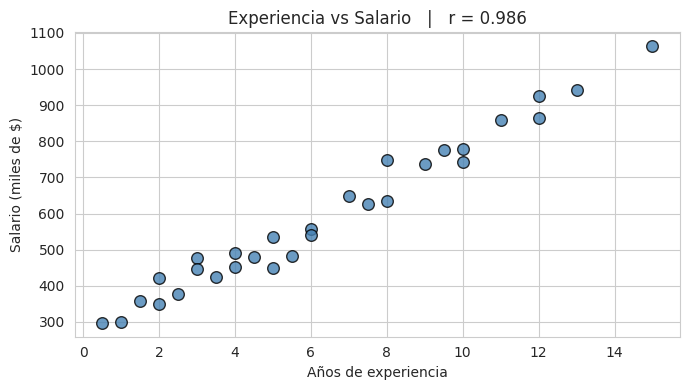

Coeficiente de correlación de Pearson: r = 0.9862
→ Hay una relación lineal positiva fuerte entre experiencia y salario.


In [ ]:
# ── Diagrama de dispersión y correlación ───────────────────

r = np.corrcoef(df.experiencia_anios, df.salario_miles)[0, 1]

plt.figure(figsize=(7, 4))
plt.scatter(df.experiencia_anios, df.salario_miles,
            color='steelblue', edgecolors='k', s=70, alpha=0.8)
plt.xlabel('Años de experiencia')
plt.ylabel('Salario (miles de $)')
plt.title(f'Experiencia vs Salario   |   r = {r:.3f}')
plt.tight_layout()
plt.show()

print(f'Coeficiente de correlación de Pearson: r = {r:.4f}')
print('→ Hay una relación lineal positiva fuerte entre experiencia y salario.')

## 2. El modelo de regresión lineal simple

Si la nube de puntos sigue una tendencia en línea recta, podemos proponer que **una recta es un buen modelo** para esa relación.

El **modelo de regresión lineal simple** tiene la forma:

$$y = \beta_0 + \beta_1 \cdot x + \varepsilon \quad \text{(modelo teórico)}$$

$$\hat{y} = b_0 + b_1 \cdot x \quad \text{(ecuación estimada con los datos)}$$

En nuestro caso:
- **Y** = salario (lo que queremos predecir)
- **X** = años de experiencia (el predictor)
- **$b_0$** = salario base (cuando X = 0 años de experiencia)
- **$b_1$** = cuánto sube el salario por cada año adicional de experiencia
- **$\varepsilon$** = error (lo que el modelo no puede explicar: talento, empresa, negociación...)

## 3. ¿Cómo encontramos la mejor recta? Mínimos Cuadrados

Hay infinitas rectas que podríamos trazar. El método de **Mínimos Cuadrados Ordinarios (OLS)** encuentra la que **minimiza la suma de los errores al cuadrado**:

$$\text{Minimizar} \quad S = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Los **residuos** son las diferencias entre los salarios reales y los que predice el modelo:

$$e_i = y_i - \hat{y}_i$$

**¿Por qué elevar al cuadrado?**
- Los errores positivos y negativos no se cancelan.
- Los errores grandes se penalizan más.
- La función es diferenciable → podemos minimizarla algebraicamente.

Las fórmulas de los coeficientes óptimos:

$$b_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad b_0 = \bar{y} - b_1 \cdot \bar{x}$$

In [ ]:
# ── Implementación MANUAL de mínimos cuadrados ─────────────

X = df.experiencia_anios.values
Y = df.salario_miles.values

x_mean = np.mean(X)
y_mean = np.mean(Y)

# Pendiente
b1 = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean)**2)
# Intercepto
b0 = y_mean - b1 * x_mean

print('=== COEFICIENTES (cálculo manual) ===')
print(f'  Intercepto b0 = {b0:.2f}')
print(f'  Pendiente  b1 = {b1:.2f}')
print()
print(f'  Ecuación estimada:')
print(f'  Salario = {b0:.1f} + {b1:.1f} × Experiencia')
print()
print('Interpretación:')
print(f'  → Un profesional con 0 años de experiencia ganaría aprox. ${b0:.0f}k')
print(f'  → Por cada año adicional de experiencia, el salario sube aprox. ${b1:.0f}k')

=== COEFICIENTES (cálculo manual) ===
  Intercepto b0 = 259.81
  Pendiente  b1 = 52.28

  Ecuación estimada:
  Salario = 259.8 + 52.3 × Experiencia

Interpretación:
  → Un profesional con 0 años de experiencia ganaría aprox. $260k
  → Por cada año adicional de experiencia, el salario sube aprox. $52k


In [ ]:
# ── Implementación con SCIKIT-LEARN ───────────────────────
# scikit-learn espera X con forma (n, 1)

# Crea una instancia del modelo de regresión lineal (aún no aprendió nada)
modelo = LinearRegression()

# Entrena el modelo: ajusta b0 y b1 minimizando el MSE sobre los datos
# .reshape(-1, 1) convierte X de array 1D a columna 2D, que sklearn requiere
modelo.fit(X.reshape(-1, 1), Y)

# Extrae el intercepto b0 (valor de Y cuando X = 0)
b0_sk = modelo.intercept_

# Extrae la pendiente b1 (cuánto sube Y por cada unidad de X)
# [0] porque coef_ es un array (habría un valor por cada predictor)
b1_sk = modelo.coef_[0]

print('=== COEFICIENTES (scikit-learn) ===')
print(f'  Intercepto b0 = {b0_sk:.2f}')
print(f'  Pendiente  b1 = {b1_sk:.2f}')
print()
print(f'¿Coinciden con el cálculo manual?')
print(f'  b0: {np.isclose(b0, b0_sk)}   b1: {np.isclose(b1, b1_sk)}')
print()
print('→ Scikit-learn implementa el mismo método de mínimos cuadrados.')
print('  La ventaja es que escala a cientos de variables sin cambiar el código.')

=== COEFICIENTES (scikit-learn) ===
  Intercepto b0 = 259.81
  Pendiente  b1 = 52.28

¿Coinciden con el cálculo manual?
  b0: True   b1: True

→ Scikit-learn implementa el mismo método de mínimos cuadrados.
  La ventaja es que escala a cientos de variables sin cambiar el código.


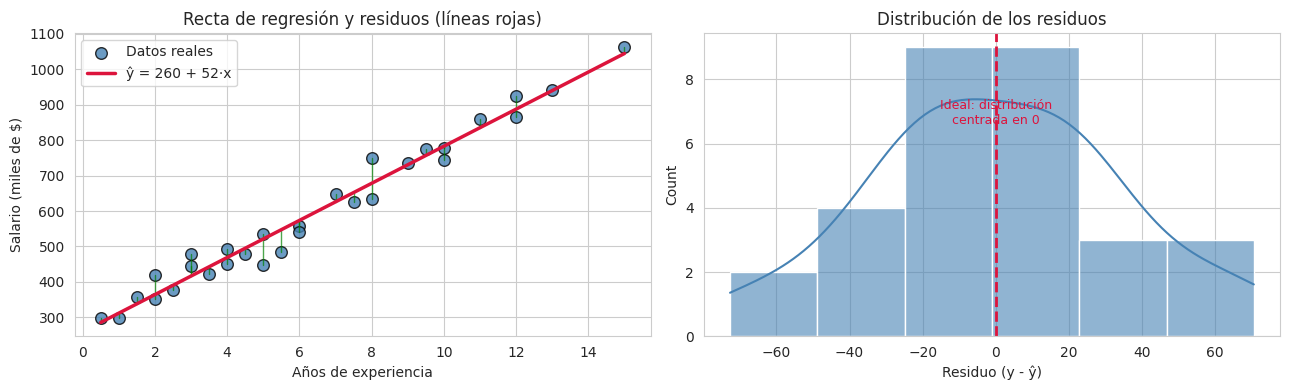

In [ ]:
# ── Visualización: datos + recta + residuos ────────────────

Y_pred = b0 + b1 * X
residuos = Y - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Gráfico 1: Datos y recta de regresión ---
ax = axes[0]
ax.scatter(X, Y, color='steelblue', edgecolors='k', s=70, alpha=0.8, label='Datos reales')

# Dibujamos algunos residuos para que se vean
for xi, yi, ypi in zip(X, Y, Y_pred):
    ax.plot([xi, xi], [yi, ypi], color='green', alpha=0.7, linewidth=1)

x_rango = np.linspace(X.min(), X.max(), 100)
ax.plot(x_rango, b0 + b1 * x_rango, color='crimson', linewidth=2.5,
        label=f'ŷ = {b0:.0f} + {b1:.0f}·x')
ax.set_xlabel('Años de experiencia')
ax.set_ylabel('Salario (miles de $)')
ax.set_title('Recta de regresión y residuos (líneas rojas)')
ax.legend()

# --- Gráfico 2: Distribución de residuos ---
ax2 = axes[1]
sns.histplot(residuos, kde=True, color='steelblue', alpha=0.6, ax=ax2)
ax2.axvline(0, color='crimson', linestyle='--', linewidth=2)
ax2.set_xlabel('Residuo (y - ŷ)')
ax2.set_title('Distribución de los residuos')
ax2.annotate('Ideal: distribución\ncentrada en 0', xy=(0, ax2.get_ylim()[1]*0.7),
             ha='center', color='crimson', fontsize=9)

plt.tight_layout()
plt.show()

## 4. ¿Qué tan bueno es el modelo?

### El coeficiente de determinación R²

El **R²** mide qué proporción de la variabilidad del salario explica el modelo:

| Sigla | Fórmula | Qué mide |
|-------|---------|----------|
| **SST** | $\sum(y_i - \bar{y})^2$ | Variabilidad total del salario |
| **SSE** | $\sum(y_i - \hat{y}_i)^2$ | Variabilidad *no* explicada (error del modelo) |
| **R²** | $1 - SSE/SST$ | Proporción explicada por el modelo |

$$R^2 = 1 - \frac{SSE}{SST}$$

### Otras métricas útiles

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Error cuadrático medio (en unidades²) |
| **RMSE** | $\sqrt{MSE}$ | Error promedio en las mismas unidades que Y |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Error absoluto promedio |

In [ ]:
# ── Métricas de evaluación ─────────────────────────────────

SST = np.sum((Y - y_mean)**2) # suma total de cuadrados
SSE = np.sum((Y - Y_pred)**2) # suma de cuadrados del error
R2  = 1 - SSE / SST # coeficiente de determinacion
MSE  = np.mean((Y - Y_pred)**2) #error cuadrado medio
RMSE = np.sqrt(MSE) #raiz del error cuadrado medio
MAE  = np.mean(np.abs(Y - Y_pred)) #error absoluto medio

print('=== MÉTRICAS DEL MODELO ===')
print(f'  R²   = {R2:.4f}')
print(f'  MSE  = {MSE:.2f}')
print(f'  RMSE = {RMSE:.2f}')
print(f'  MAE  = {MAE:.2f}')
print()
print('Interpretación:')
print(f'  → El modelo explica el {R2*100:.1f}% de la variabilidad salarial.')
print(f'  → En promedio, la predicción de salario se equivoca en ±${RMSE:.0f}k.')
print(f'  → El {100-R2*100:.1f}% restante depende de factores no incluidos')
print(f'    (empresa, habilidades específicas, negociación, etc.)')

=== MÉTRICAS DEL MODELO ===
  R²   = 0.9725
  MSE  = 1142.89
  RMSE = 33.81
  MAE  = 27.68

Interpretación:
  → El modelo explica el 97.3% de la variabilidad salarial.
  → En promedio, la predicción de salario se equivoca en ±$34k.
  → El 2.7% restante depende de factores no incluidos
    (empresa, habilidades específicas, negociación, etc.)


In [ ]:
# ── Usando el modelo para predecir ────────────────────────
# ¿Cuánto debería ganar alguien con 3, 5 y 10 años de experiencia?

casos = pd.DataFrame({'experiencia_anios': [3, 5, 10]})
casos['salario_predicho_miles'] = modelo.predict(casos[['experiencia_anios']])

print('=== PREDICCIONES ===')
for _, row in casos.iterrows():
    print(f'  {int(row.experiencia_anios)} años de experiencia → salario estimado: ${row.salario_predicho_miles:.0f}k/mes')

print()
print('Recordá: son estimaciones basadas en el promedio del dataset.')
print(f'El margen de error del modelo es de aproximadamente ±${RMSE:.0f}k.')

=== PREDICCIONES ===
  3 años de experiencia → salario estimado: $417k/mes
  5 años de experiencia → salario estimado: $521k/mes
  10 años de experiencia → salario estimado: $783k/mes

Recordá: son estimaciones basadas en el promedio del dataset.
El margen de error del modelo es de aproximadamente ±$34k.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## 5. Supuestos del modelo

Para que el modelo sea válido, los **residuos** deben cumplir cuatro condiciones:

| Supuesto | Qué significa | ¿Cómo verificarlo? |
|----------|--------------|--------------------|
| **Linealidad** | La relación X-Y es lineal | Gráfico de dispersión |
| **Independencia** | Los errores no están correlacionados | Contexto del problema |
| **Homocedasticidad** | La varianza del error es constante | Gráfico residuos vs ŷ |
| **Normalidad** | Los errores siguen una normal con media 0 | Histograma de residuos |

Si alguno se viola, el modelo puede dar estimaciones incorrectas.

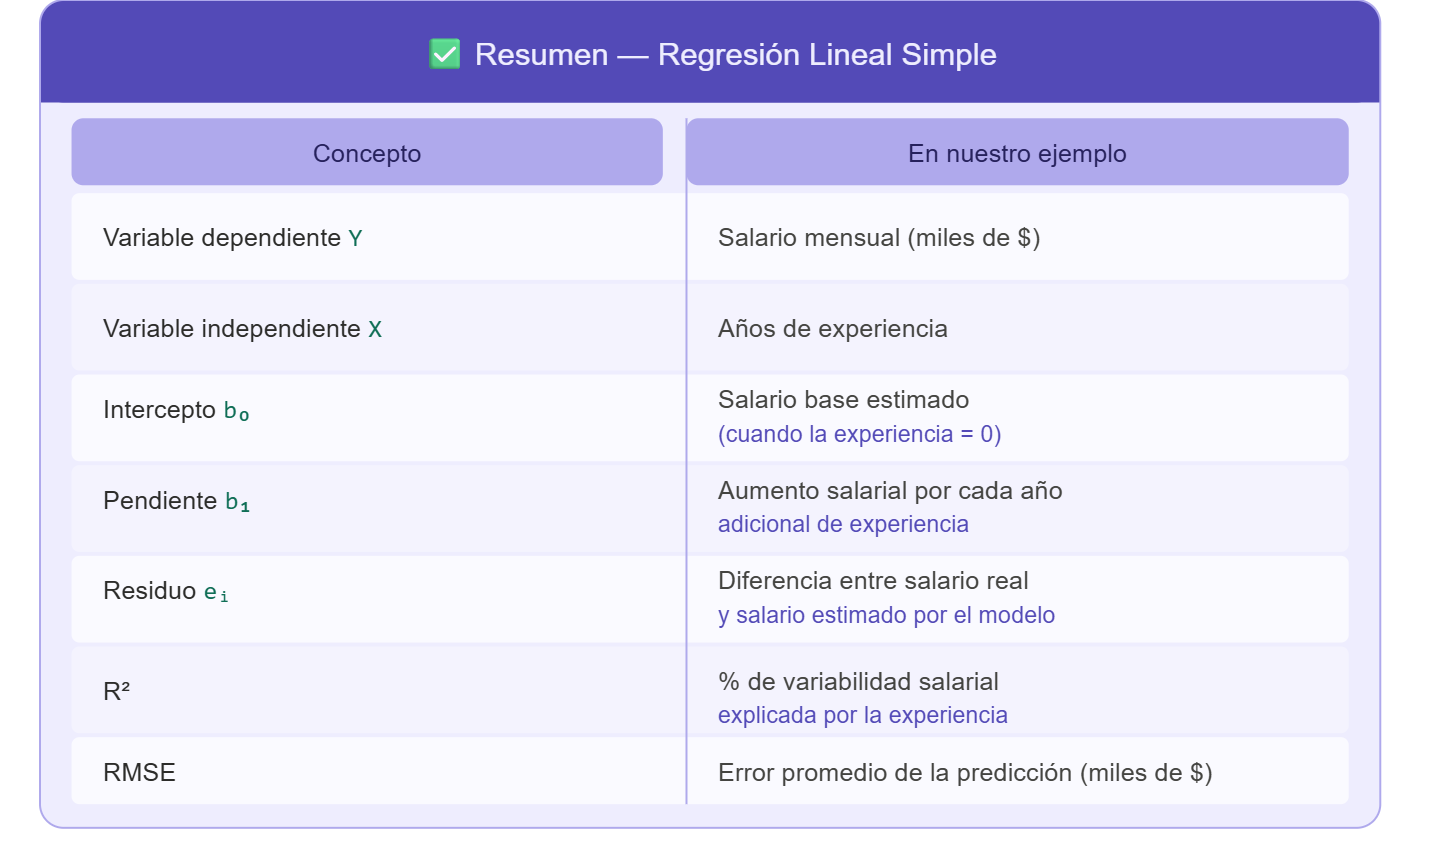


---
*Ciencia de Datos · CLCD 121 · Universidad del Gran Rosario*